# 🔬 Publication-Quality Skin Cancer Classification: Baseline Comparison & Proposed Optimization Framework
> **Dataset**: Kaggle Benchmark (`fanconic/skin-cancer-malignant-vs-benign`)  
> **Task**: Binary Melanoma Classification (0 = Benign, 1 = Malignant)  
> **Methodology**: 12-Stage Research Pipeline — Stratified Data Partitioning, 4-Model Baseline Evaluation, Validation-Based Strongest Baseline Identification, Framework Optimization (Head Regularization, BatchNorm Freezing, Focal Loss), Validation Threshold Tuning, Dynamic Proposed Model Selection, Ablation Analysis, Final Benchmark Test Evaluation, and Graph-Connected Grad-CAM Explainability.


## ⚙️ 1. Environment Setup & Global Reproducibility

Enforcing global reproducibility across Python, NumPy, and TensorFlow environments (`SEED = 42`).
Inspecting system hardware specifications, GPU availability, and library dependencies.


In [1]:
import os
import sys
import random
import glob
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import ResNet50, DenseNet121, EfficientNetB4
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_preprocess

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay, precision_recall_curve
)

# ── Global Reproducibility ───────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('=' * 65)
print('  SYSTEM ENVIRONMENT & DEPENDENCIES')
print('=' * 65)
print(f'  TensorFlow Version : {tf.__version__}')
print(f'  Python Version     : {sys.version.split()[0]}')
print(f'  GPU Devices        : {tf.config.list_physical_devices("GPU")}')
print(f'  Global Random Seed : {SEED}')
print('=' * 65)


  SYSTEM ENVIRONMENT & DEPENDENCIES
  TensorFlow Version : 2.20.0
  Python Version     : 3.12.13
  GPU Devices        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
  Global Random Seed : 42


## 📊 2. Official Dataset Inspection & Stratified Train/Val Split

**Benchmark Data Partitioning Protocol**:
- `data/test`: **660 images** — Held out completely untouched for final evaluation ONLY.
- `data/train`: **2,637 images** — Split 80/20 using stratified partitioning (`train_test_split(stratify=train_labels, random_state=42)`):
  - **Training Set (80%)**: 2,109 images (1,152 Benign / 957 Malignant)
  - **Validation Set (20%)**: 528 images (288 Benign / 240 Malignant)


Official Training Set Images : 2637
  Benign    : 1440
  Malignant : 1197
Official Benchmark Test Set  : 660 (UNTOUCHED & UN-POOLED)
  Benign    : 360
  Malignant : 300

  EXPERIMENTAL DATASET SPLIT STATISTICS
                       Split  Total % Total  Benign  Malignant B:M Ratio
     Train (from data/train)   2109   64.0%    1152        957    1.20:1
Validation (from data/train)    528   16.0%     288        240    1.20:1
   Official Test (data/test)    660   20.0%     360        300    1.20:1


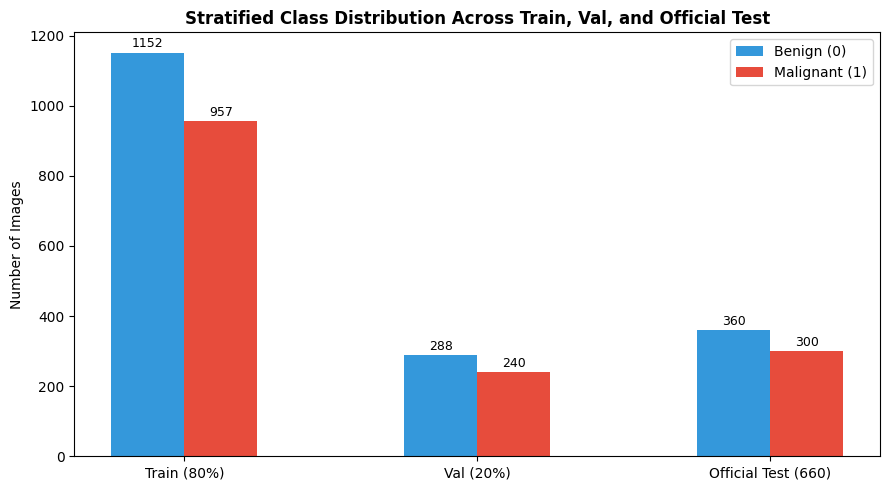

In [2]:
DATA_DIR = "/kaggle/input/datasets/fanconic/skin-cancer-malignant-vs-benign"
EXTS = ('.jpg', '.jpeg', '.png', '.bmp')

def collect_labeled_filepaths(base_dir):
    filepaths = []
    labels = []
    class_names = sorted([d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))])
    for label_idx, class_name in enumerate(class_names):
        class_dir = os.path.join(base_dir, class_name)
        for fname in os.listdir(class_dir):
            if fname.lower().endswith(EXTS):
                filepaths.append(os.path.join(class_dir, fname))
                labels.append(label_idx)
    return np.array(filepaths), np.array(labels), class_names

# Load official train and official test folders independently
raw_train_files, raw_train_labels, CLASS_NAMES = collect_labeled_filepaths(os.path.join(DATA_DIR, 'train'))
X_test, y_test, _ = collect_labeled_filepaths(os.path.join(DATA_DIR, 'test'))

print(f'Official Training Set Images : {len(raw_train_files)}')
print(f'  Benign    : {int(np.sum(raw_train_labels == 0))}')
print(f'  Malignant : {int(np.sum(raw_train_labels == 1))}')
print(f'Official Benchmark Test Set  : {len(X_test)} (UNTOUCHED & UN-POOLED)')
print(f'  Benign    : {int(np.sum(y_test == 0))}')
print(f'  Malignant : {int(np.sum(y_test == 1))}')

# Stratified 80/20 Train/Validation Split (Exclusively on data/train)
X_train, X_val, y_train, y_val = train_test_split(
    raw_train_files, raw_train_labels,
    test_size=0.20,
    stratify=raw_train_labels,
    random_state=SEED
)

print('\n' + '=' * 65)
print('  EXPERIMENTAL DATASET SPLIT STATISTICS')
print('=' * 65)
splits_info = {
    'Train (from data/train)': (X_train, y_train),
    'Validation (from data/train)': (X_val, y_val),
    'Official Test (data/test)': (X_test, y_test)
}

split_table_data = []
total_all = len(raw_train_files) + len(X_test)
for sname, (sX, sy) in splits_info.items():
    scount = len(sX)
    b_c = int(np.sum(sy == 0))
    m_c = int(np.sum(sy == 1))
    ratio = b_c / max(1, m_c)
    pct = (scount / total_all) * 100
    split_table_data.append({
        'Split': sname, 'Total': scount, '% Total': f'{pct:.1f}%',
        'Benign': b_c, 'Malignant': m_c, 'B:M Ratio': f'{ratio:.2f}:1'
    })

split_df = pd.DataFrame(split_table_data)
print(split_df.to_string(index=False))
print('=' * 65)

# Visualization: Class Distribution Bar Chart
fig, ax = plt.subplots(figsize=(9, 5))
bar_width = 0.25
x_indices = np.arange(len(splits_info))
b_counts = [int(np.sum(sy == 0)) for _, sy in splits_info.values()]
m_counts = [int(np.sum(sy == 1)) for _, sy in splits_info.values()]

ax.bar(x_indices - bar_width/2, b_counts, bar_width, label='Benign (0)', color='#3498db')
ax.bar(x_indices + bar_width/2, m_counts, bar_width, label='Malignant (1)', color='#e74c3c')
ax.set_title('Stratified Class Distribution Across Train, Val, and Official Test', fontsize=12, fontweight='bold')
ax.set_xticks(x_indices)
ax.set_xticklabels(['Train (80%)', 'Val (20%)', 'Official Test (660)'])
ax.set_ylabel('Number of Images')
ax.legend()
for i in x_indices:
    ax.text(i - bar_width/2, b_counts[i] + 15, str(b_counts[i]), ha='center', fontsize=9)
    ax.text(i + bar_width/2, m_counts[i] + 15, str(m_counts[i]), ha='center', fontsize=9)
plt.tight_layout()
plt.show()


## 🔄 3. Data Pipeline & Dedicated Input Preprocessing

We build dedicated, non-overlapping input data pipelines (`tf.data.Dataset`) for each model family:
- **Custom CNN**: 224 x 224 x 3 (`custom_cnn_preprocess = img / 255.0`)
- **ResNet50**: 224 x 224 x 3 (`resnet_preprocess`)
- **DenseNet121**: 224 x 224 x 3 (`densenet_preprocess`)
- **EfficientNet-B4**: 380 x 380 x 3 (`preprocess_fn=None`, raw [0, 255] float tensors fed to native internal rescaling/normalization layers)

**Training-Only Augmentation**: Horizontal flip, small rotations ($\pm 18^\circ$), zoom ($\pm 10\%$), contrast ($\pm 10\%$). Applied **ONLY to training datasets** before model preprocessing.


In [3]:
AUTOTUNE = tf.data.AUTOTUNE
BATCH_SIZE_224 = 32
BATCH_SIZE_380 = 16

# Train-only Data Augmentation Pipeline
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10),
], name='train_data_augmentation')

def load_and_resize_raw_image(path_tensor, label_tensor, img_size):
    raw_bytes = tf.io.read_file(path_tensor)
    img = tf.image.decode_jpeg(raw_bytes, channels=3)
    img = tf.image.resize(img, img_size)
    img = tf.cast(img, tf.float32)
    return img, tf.cast(label_tensor, tf.float32)

def build_tf_dataset(filepaths, labels, img_size, batch_size, is_training=False, preprocess_fn=None):
    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))
    ds = ds.map(lambda p, l: load_and_resize_raw_image(p, l, img_size), num_parallel_calls=AUTOTUNE)
    if is_training:
        ds = ds.shuffle(buffer_size=len(filepaths), seed=SEED)
        ds = ds.map(lambda img, lbl: (data_augmentation(img, training=True), lbl), num_parallel_calls=AUTOTUNE)
    if preprocess_fn is not None:
        ds = ds.map(lambda img, lbl: (preprocess_fn(img), lbl), num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(buffer_size=AUTOTUNE)
    return ds

def custom_cnn_preprocess(img):
    return img / 255.0

# Build dedicated dataset instances per architecture family
train_ds_cnn = build_tf_dataset(X_train, y_train, (224, 224), BATCH_SIZE_224, is_training=True, preprocess_fn=custom_cnn_preprocess)
val_ds_cnn   = build_tf_dataset(X_val, y_val, (224, 224), BATCH_SIZE_224, is_training=False, preprocess_fn=custom_cnn_preprocess)
test_ds_cnn  = build_tf_dataset(X_test, y_test, (224, 224), BATCH_SIZE_224, is_training=False, preprocess_fn=custom_cnn_preprocess)

train_ds_res = build_tf_dataset(X_train, y_train, (224, 224), BATCH_SIZE_224, is_training=True, preprocess_fn=resnet_preprocess)
val_ds_res   = build_tf_dataset(X_val, y_val, (224, 224), BATCH_SIZE_224, is_training=False, preprocess_fn=resnet_preprocess)
test_ds_res  = build_tf_dataset(X_test, y_test, (224, 224), BATCH_SIZE_224, is_training=False, preprocess_fn=resnet_preprocess)

train_ds_dense = build_tf_dataset(X_train, y_train, (224, 224), BATCH_SIZE_224, is_training=True, preprocess_fn=densenet_preprocess)
val_ds_dense   = build_tf_dataset(X_val, y_val, (224, 224), BATCH_SIZE_224, is_training=False, preprocess_fn=densenet_preprocess)
test_ds_dense  = build_tf_dataset(X_test, y_test, (224, 224), BATCH_SIZE_224, is_training=False, preprocess_fn=densenet_preprocess)

train_ds_eff = build_tf_dataset(X_train, y_train, (380, 380), BATCH_SIZE_380, is_training=True, preprocess_fn=None)
val_ds_eff   = build_tf_dataset(X_val, y_val, (380, 380), BATCH_SIZE_380, is_training=False, preprocess_fn=None)
test_ds_eff  = build_tf_dataset(X_test, y_test, (380, 380), BATCH_SIZE_380, is_training=False, preprocess_fn=None)

print('Dedicated tf.data pipelines initialized for Custom CNN, ResNet50, DenseNet121, and EfficientNet-B4.')


I0000 00:00:1786282331.141828      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1786282331.145513      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Dedicated tf.data pipelines initialized for Custom CNN, ResNet50, DenseNet121, and EfficientNet-B4.


## 🏗️ 4. Baseline Models Phase

We construct and train 4 baseline models to establish baseline performance:
1. **Custom CNN Baseline**: 4-block Conv2D + BN + ReLU + MaxPool.
2. **ResNet50 Baseline**: Transfer learning baseline (ImageNet pre-trained).
3. **DenseNet121 Baseline**: Dense connectivity baseline (ImageNet pre-trained).
4. **EfficientNet-B4 Baseline**: Compound scaling baseline (ImageNet pre-trained).


### 4.1 Custom CNN Baseline

In [4]:
def build_custom_cnn(input_shape=(224, 224, 3)):
    inputs = layers.Input(shape=input_shape)
    x = inputs
    x = layers.Conv2D(32, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    
    x = layers.Conv2D(64, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    
    x = layers.Conv2D(128, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    
    x = layers.Conv2D(256, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)
    
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    return models.Model(inputs, outputs, name='Custom_CNN_Baseline')

model_cnn = build_custom_cnn()
model_cnn.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

callbacks_cnn = [
    callbacks.ModelCheckpoint('best_custom_cnn.keras', monitor='val_auc', mode='max', save_best_only=True, verbose=0),
    callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=8, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.5, patience=4, min_lr=1e-6, verbose=1)
]

print('Training Custom CNN Baseline...')
history_cnn = model_cnn.fit(train_ds_cnn, validation_data=val_ds_cnn, epochs=25, callbacks=callbacks_cnn, verbose=1)
print('Custom CNN Baseline training complete.')


Training Custom CNN Baseline...
Epoch 1/25
 2/66 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - accuracy: 0.5000 - auc: 0.5977 - loss: 0.8486  

I0000 00:00:1786282355.486921     132 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


66/66 ━━━━━━━━━━━━━━━━━━━━ 46s 392ms/step - accuracy: 0.7587 - auc: 0.8441 - loss: 0.4927 - val_accuracy: 0.5455 - val_auc: 0.8454 - val_loss: 1.0010 - learning_rate: 0.0010
Epoch 2/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 18s 237ms/step - accuracy: 0.7876 - auc: 0.8783 - loss: 0.4224 - val_accuracy: 0.5473 - val_auc: 0.8391 - val_loss: 0.7574 - learning_rate: 0.0010
Epoch 3/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 18s 235ms/step - accuracy: 0.7923 - auc: 0.8791 - loss: 0.4232 - val_accuracy: 0.5720 - val_auc: 0.8323 - val_loss: 0.6505 - learning_rate: 0.0010
Epoch 4/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 18s 239ms/step - accuracy: 0.7904 - auc: 0.8835 - loss: 0.4093 - val_accuracy: 0.6894 - val_auc: 0.8640 - val_loss: 0.4979 - learning_rate: 0.0010
Epoch 5/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 17s 238ms/step - accuracy: 0.8056 - auc: 0.8983 - loss: 0.3909 - val_accuracy: 0.7386 - val_auc: 0.8654 - val_loss: 0.5232 - learning_rate: 0.0010
Epoch 6/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 18s 237ms/step - accuracy: 0.8042 - auc: 0.8877 

### 4.2 ResNet50 Baseline

In [5]:
def build_resnet50_model(input_shape=(224, 224, 3)):
    base_resnet = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
    base_resnet.trainable = False
    inputs = layers.Input(shape=input_shape)
    #x = base_resnet(inputs, training=False)
    x = base_resnet(inputs)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    return models.Model(inputs, outputs, name='ResNet50_Baseline'), base_resnet

model_res, base_res = build_resnet50_model()

# Stage 1: Frozen Backbone
model_res.compile(optimizer=optimizers.Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
callbacks_res_s1 = [
    callbacks.ModelCheckpoint('best_resnet50_stage1.keras', monitor='val_auc', mode='max', save_best_only=True, verbose=0),
    callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=6, restore_best_weights=True, verbose=1)
]
print('Stage 1: Training ResNet50 Head (Backbone Frozen)...')
history_res_s1 = model_res.fit(train_ds_res, validation_data=val_ds_res, epochs=25, callbacks=callbacks_res_s1, verbose=1)

# Stage 2: Fine-Tuning (BatchNorm Frozen)
base_res.trainable = True
unfreeze_from = int(len(base_res.layers) * 0.75)
for idx, layer in enumerate(base_res.layers):
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False
    elif idx < unfreeze_from:
        layer.trainable = False

model_res.compile(optimizer=optimizers.Adam(1e-5), loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
callbacks_res_s2 = [
    callbacks.ModelCheckpoint('best_resnet50_final.keras', monitor='val_auc', mode='max', save_best_only=True, verbose=0),
    callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=8, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.5, patience=4, min_lr=1e-7, verbose=1)
]
print('Stage 2: Fine-tuning ResNet50 (BatchNorm Layers Frozen)...')
history_res_s2 = model_res.fit(train_ds_res, validation_data=val_ds_res, epochs=25, callbacks=callbacks_res_s2, verbose=1)
print('ResNet50 Baseline training complete.')


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Stage 1: Training ResNet50 Head (Backbone Frozen)...
Epoch 1/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 53s 531ms/step - accuracy: 0.7335 - auc: 0.8116 - loss: 0.5861 - val_accuracy: 0.8295 - val_auc: 0.9153 - val_loss: 0.3695
Epoch 2/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 21s 289ms/step - accuracy: 0.8293 - auc: 0.9060 - loss: 0.4045 - val_accuracy: 0.8466 - val_auc: 0.9331 - val_loss: 0.3322
Epoch 3/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 21s 291ms/step - accuracy: 0.8326 - auc: 0.9145 - loss: 0.3877 - val_accuracy: 0.8598 - val_auc: 0.9394 - val_loss: 0.3248
Epoch 4/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 21s 291ms/step - accuracy: 0.8554 - auc: 0.9317 - loss: 0.3369 - val_accuracy: 0.8561 - val_auc: 0.9465 - val_loss: 0.2954
Epoch 5/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 20s 274ms/step - accuracy: 0.8559 - auc: 0.9314 - loss: 0.3382 - val_accuracy: 0.8617 - val_auc: 0.9455 - val_loss: 0.3024
Epoch 6/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 20s 271ms/step - accuracy: 0.8639 - auc: 0.9428 - los

### 4.3 DenseNet121 Baseline

In [6]:
def build_densenet121_model(input_shape=(224, 224, 3)):
    base_dense = DenseNet121(weights='imagenet', include_top=False, input_shape=input_shape)
    base_dense.trainable = False
    inputs = layers.Input(shape=input_shape)
    x = base_dense(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    return models.Model(inputs, outputs, name='DenseNet121_Baseline'), base_dense

model_dense, base_dense = build_densenet121_model()

# Stage 1: Frozen Backbone
model_dense.compile(optimizer=optimizers.Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
callbacks_dense_s1 = [
    callbacks.ModelCheckpoint('best_densenet121_stage1.keras', monitor='val_auc', mode='max', save_best_only=True, verbose=0),
    callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=6, restore_best_weights=True, verbose=1)
]
print('Stage 1: Training DenseNet121 Head (Backbone Frozen)...')
history_dense_s1 = model_dense.fit(train_ds_dense, validation_data=val_ds_dense, epochs=25, callbacks=callbacks_dense_s1, verbose=1)

# Stage 2: Fine-Tuning (BatchNorm Frozen)
base_dense.trainable = True
unfreeze_from_d = int(len(base_dense.layers) * 0.75)
for idx, layer in enumerate(base_dense.layers):
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False
    elif idx < unfreeze_from_d:
        layer.trainable = False

model_dense.compile(optimizer=optimizers.Adam(1e-5), loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
callbacks_dense_s2 = [
    callbacks.ModelCheckpoint('best_densenet121_final.keras', monitor='val_auc', mode='max', save_best_only=True, verbose=0),
    callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=8, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.5, patience=4, min_lr=1e-7, verbose=1)
]
print('Stage 2: Fine-tuning DenseNet121 (BatchNorm Layers Frozen)...')
history_dense_s2 = model_dense.fit(train_ds_dense, validation_data=val_ds_dense, epochs=25, callbacks=callbacks_dense_s2, verbose=1)
print('DenseNet121 Baseline training complete.')


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Stage 1: Training DenseNet121 Head (Backbone Frozen)...
Epoch 1/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 97s 965ms/step - accuracy: 0.6923 - auc: 0.7665 - loss: 0.5962 - val_accuracy: 0.8182 - val_auc: 0.8971 - val_loss: 0.4441
Epoch 2/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 21s 287ms/step - accuracy: 0.8056 - auc: 0.8888 - loss: 0.4232 - val_accuracy: 0.8182 - val_auc: 0.9140 - val_loss: 0.4062
Epoch 3/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 21s 287ms/step - accuracy: 0.8103 - auc: 0.8973 - loss: 0.4055 - val_accuracy: 0.8220 - val_auc: 0.9222 - val_loss: 0.3877
Epoch 4/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 21s 286ms/step - accuracy: 0.8284 - auc: 0.9113 - loss: 0.3777 - val_accuracy: 0.8295 - val_auc: 0.9276 - val_loss: 0.3589
Epoch 5/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 21s 287ms/step - accuracy: 0.8284 - auc: 0.9163 - loss: 0.3673 - val_accuracy: 0.8295 - val_auc: 0.9304 - val_loss: 0.3566
Epoch 6/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 21s 286ms/step - accuracy: 0.8440 - auc: 0.9246 - 

### 4.4 EfficientNet-B4 Baseline

In [7]:
def focal_loss(gamma=2.0, alpha=0.55):
    def binary_focal_loss(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        bce = -(y_true * tf.math.log(y_pred) + (1.0 - y_true) * tf.math.log(1.0 - y_pred))
        p_t = tf.where(tf.equal(y_true, 1), y_pred, 1.0 - y_pred)
        alpha_t = tf.where(tf.equal(y_true, 1), tf.ones_like(y_true) * alpha, tf.ones_like(y_true) * (1.0 - alpha))
        loss = alpha_t * tf.pow(1.0 - p_t, gamma) * bce
        return tf.reduce_mean(loss)
    binary_focal_loss.__name__ = 'binary_focal_loss'
    return binary_focal_loss

def build_efficientnet_b4_model(input_shape=(380, 380, 3)):
    try:
        base_b4 = EfficientNetB4(weights='imagenet', include_top=False, include_preprocessing=True, input_shape=input_shape)
    except TypeError:
        base_b4 = EfficientNetB4(weights='imagenet', include_top=False, input_shape=input_shape)
    base_b4.trainable = False
    
    inputs = layers.Input(shape=input_shape)
    x = base_b4(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(512, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.40)(x)
    x = layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.30)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    return models.Model(inputs, outputs, name='EfficientNet_B4_Baseline'), base_b4

model_eff, base_eff = build_efficientnet_b4_model()

# Stage 1: Frozen Backbone
model_eff.compile(optimizer=optimizers.Adam(1e-3), loss=focal_loss(2.0, 0.55), metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
callbacks_eff_s1 = [
    callbacks.ModelCheckpoint('best_effnet_stage1.keras', monitor='val_auc', mode='max', save_best_only=True, verbose=0),
    callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=8, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.5, patience=4, min_lr=1e-6, verbose=1)
]
print('Stage 1: Training EfficientNet-B4 Head (Backbone Frozen)...')
history_eff_s1 = model_eff.fit(train_ds_eff, validation_data=val_ds_eff, epochs=25, callbacks=callbacks_eff_s1, verbose=1)

# Stage 2: Fine-Tuning (BatchNorm Frozen)
base_eff.trainable = True
unfreeze_from_e = int(len(base_eff.layers) * 0.75)
for idx, layer in enumerate(base_eff.layers):
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False
    elif idx < unfreeze_from_e:
        layer.trainable = False

model_eff.compile(optimizer=optimizers.Adam(3e-5), loss=focal_loss(2.0, 0.55), metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
callbacks_eff_s2 = [
    callbacks.ModelCheckpoint('best_effnet_final.keras', monitor='val_auc', mode='max', save_best_only=True, verbose=0),
    callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=10, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.5, patience=4, min_lr=1e-7, verbose=1)
]
print('Stage 2: Fine-tuning EfficientNet-B4 (BatchNorm Layers Frozen)...')
history_eff_s2 = model_eff.fit(train_ds_eff, validation_data=val_ds_eff, epochs=25, callbacks=callbacks_eff_s2, verbose=1)
print('EfficientNet-B4 Baseline training complete.')


71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Stage 1: Training EfficientNet-B4 Head (Backbone Frozen)...
Epoch 1/25


2026-08-09 14:15:26.448654: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-09 14:15:26.595255: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-09 14:15:26.895020: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-09 14:15:27.042868: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-09 14:15:27.430136: E external/local_xla/xla/stream_

131/132 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step - accuracy: 0.7048 - auc: 0.7785 - loss: 0.3471

2026-08-09 14:16:45.227640: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-09 14:16:45.370035: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-09 14:16:45.644427: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-09 14:16:45.789293: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-09 14:16:46.110497: E external/local_xla/xla/stream_

132/132 ━━━━━━━━━━━━━━━━━━━━ 171s 770ms/step - accuracy: 0.7274 - auc: 0.8074 - loss: 0.3179 - val_accuracy: 0.7973 - val_auc: 0.8825 - val_loss: 0.1746 - learning_rate: 0.0010
Epoch 2/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 50s 345ms/step - accuracy: 0.7606 - auc: 0.8494 - loss: 0.2058 - val_accuracy: 0.8333 - val_auc: 0.9200 - val_loss: 0.1703 - learning_rate: 0.0010
Epoch 3/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 48s 330ms/step - accuracy: 0.8004 - auc: 0.8892 - loss: 0.1733 - val_accuracy: 0.8258 - val_auc: 0.9148 - val_loss: 0.1653 - learning_rate: 0.0010
Epoch 4/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 49s 343ms/step - accuracy: 0.8189 - auc: 0.9005 - loss: 0.1668 - val_accuracy: 0.8352 - val_auc: 0.9272 - val_loss: 0.1568 - learning_rate: 0.0010
Epoch 5/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 49s 345ms/step - accuracy: 0.8132 - auc: 0.9050 - loss: 0.1605 - val_accuracy: 0.8390 - val_auc: 0.9331 - val_loss: 0.1515 - learning_rate: 0.0010
Epoch 6/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 47s 333ms/step - accuracy: 0.8293 -

2026-08-09 14:37:36.064040: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-09 14:37:36.219878: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-09 14:37:36.692716: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-09 14:37:36.832727: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-09 14:37:37.161358: E external/local_xla/xla/stream_

131/132 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step - accuracy: 0.8963 - auc: 0.9685 - loss: 0.0819

2026-08-09 14:38:58.958842: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-09 14:38:59.117318: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-09 14:38:59.274783: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-09 14:38:59.815118: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-09 14:38:59.971195: E external/local_xla/xla/stream_

132/132 ━━━━━━━━━━━━━━━━━━━━ 181s 808ms/step - accuracy: 0.8924 - auc: 0.9665 - loss: 0.0828 - val_accuracy: 0.8731 - val_auc: 0.9519 - val_loss: 0.0882 - learning_rate: 3.0000e-05
Epoch 2/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 57s 400ms/step - accuracy: 0.9037 - auc: 0.9740 - loss: 0.0773 - val_accuracy: 0.8617 - val_auc: 0.9528 - val_loss: 0.0962 - learning_rate: 3.0000e-05
Epoch 3/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 56s 397ms/step - accuracy: 0.9128 - auc: 0.9737 - loss: 0.0764 - val_accuracy: 0.8807 - val_auc: 0.9588 - val_loss: 0.0874 - learning_rate: 3.0000e-05
Epoch 4/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 54s 383ms/step - accuracy: 0.9189 - auc: 0.9800 - loss: 0.0723 - val_accuracy: 0.8769 - val_auc: 0.9547 - val_loss: 0.0961 - learning_rate: 3.0000e-05
Epoch 5/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 54s 381ms/step - accuracy: 0.9251 - auc: 0.9823 - loss: 0.0705 - val_accuracy: 0.8845 - val_auc: 0.9529 - val_loss: 0.0904 - learning_rate: 3.0000e-05
Epoch 6/25
132/132 ━━━━━━━━━━━━━━━━━━━━ 54s 381ms/step 

## 📊 5. Baseline Model Comparison

We evaluate all 4 baseline models on the **Validation set (`val_ds_*`)** to compare diagnostic metrics prior to optimization.


In [8]:
def compute_val_metrics(y_true, y_probs, th=0.50):
    preds = (y_probs >= th).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
    acc = (tp + tn) / len(y_true)
    prec = tp / max(1, tp + fp)
    sens = tp / max(1, tp + fn)
    spec = tn / max(1, tn + fp)
    f1 = 2 * prec * sens / max(1e-7, prec + sens)
    auc = roc_auc_score(y_true, y_probs)
    return acc * 100, prec * 100, sens * 100, spec * 100, f1 * 100, auc * 100

baseline_models = {
    'Custom CNN Baseline': (model_cnn, val_ds_cnn),
    'ResNet50 Baseline': (model_res, val_ds_res),
    'DenseNet121 Baseline': (model_dense, val_ds_dense),
    'EfficientNet-B4 Baseline': (model_eff, val_ds_eff)
}

baseline_val_results = []
for bname, (bmobj, bvds) in baseline_models.items():
    vprobs = bmobj.predict(bvds, verbose=0).ravel()
    acc, prec, sens, spec, f1, auc = compute_val_metrics(y_val, vprobs, th=0.50)
    baseline_val_results.append({
        'Model': bname, 'Val Accuracy': f'{acc:.2f}%', 'Val Precision': f'{prec:.2f}%',
        'Val Sensitivity': f'{sens:.2f}%', 'Val Specificity': f'{spec:.2f}%',
        'Val F1-Score': f'{f1:.2f}%', 'Val ROC-AUC': f'{auc:.2f}%',
        '_auc': auc, '_f1': f1, '_sens': sens, '_acc': acc
    })

print('=' * 85)
print('  BASELINE MODEL COMPARISON TABLE (VALIDATION SET)')
print('=' * 85)
baseline_val_df = pd.DataFrame(baseline_val_results)
print(baseline_val_df.drop(columns=['_auc', '_f1', '_sens', '_acc']).to_string(index=False))
print('=' * 85)


  BASELINE MODEL COMPARISON TABLE (VALIDATION SET)
                   Model Val Accuracy Val Precision Val Sensitivity Val Specificity Val F1-Score Val ROC-AUC
     Custom CNN Baseline       84.28%        79.62%          87.92%          81.25%       83.56%      93.41%
       ResNet50 Baseline       87.88%        90.37%          82.08%          92.71%       86.03%      96.20%
    DenseNet121 Baseline       85.80%        85.41%          82.92%          88.19%       84.14%      94.40%
EfficientNet-B4 Baseline       88.07%        91.16%          81.67%          93.40%       86.15%      95.87%


## 🏆 6. Strongest Baseline Model Selection

We dynamically identify the **strongest baseline model** using **Validation metrics ONLY**.
**Priority Rule**: Validation ROC-AUC (1st) $\rightarrow$ Validation F1-score (2nd) $\rightarrow$ Validation Sensitivity (3rd) $\rightarrow$ Validation Accuracy (4th).


In [9]:
sorted_baselines = sorted(
    baseline_val_results,
    key=lambda x: (x['_auc'], x['_f1'], x['_sens'], x['_acc']),
    reverse=True
)

top_baseline = sorted_baselines[0]
strongest_baseline_model_name = top_baseline['Model'].replace(' Baseline', '')

print('=' * 85)
print('  STRONGEST BASELINE MODEL SELECTION (VALIDATION-ONLY PROTOCOL)')
print('=' * 85)
print(f'  strongest_baseline_model_name : "{strongest_baseline_model_name}"')
print(f'  Selected Model Full Title     : {top_baseline["Model"]}')
print(f'  Validation ROC-AUC            : {top_baseline["Val ROC-AUC"]}')
print(f'  Validation F1-Score           : {top_baseline["Val F1-Score"]}')
print(f'  Validation Sensitivity        : {top_baseline["Val Sensitivity"]}')
print(f'  Validation Specificity        : {top_baseline["Val Specificity"]}')
print(f'  Validation Accuracy           : {top_baseline["Val Accuracy"]}')
print('=' * 85)
print(f'Conclusion: The optimization phase in Section 7 will target {strongest_baseline_model_name}.')


  STRONGEST BASELINE MODEL SELECTION (VALIDATION-ONLY PROTOCOL)
  strongest_baseline_model_name : "ResNet50"
  Selected Model Full Title     : ResNet50 Baseline
  Validation ROC-AUC            : 96.20%
  Validation F1-Score           : 86.03%
  Validation Sensitivity        : 82.08%
  Validation Specificity        : 92.71%
  Validation Accuracy           : 87.88%
Conclusion: The optimization phase in Section 7 will target ResNet50.


## 🛠️ 7. Optimization Phase: Strongest Baseline Framework Optimization

Having identified **ResNet50** as the strongest baseline model in Section 6, we create the **Optimized ResNet50 Framework**:
- **Improved Dense Head**: `GlobalAveragePooling2D` $\rightarrow$ `Dense(512, relu, L2(1e-4))` $\rightarrow$ `BatchNormalization()` $\rightarrow$ `Dropout(0.4)` $\rightarrow$ `Dense(256, relu, L2(1e-4))` $\rightarrow$ `Dropout(0.3)` $\rightarrow$ `Dense(1, sigmoid)`.
- **Stage 1 (Frozen Backbone)**: Train classification head (`Adam(1e-3)`).
- **Stage 2 (Fine-Tuning)**: Unfreeze top 25% of layers. **All BatchNormalization layers remain explicitly frozen** (`layer.trainable = False`).
- **Loss Experiments**: Binary Cross-Entropy (BCE) vs. Binary Focal Loss (FL, $\gamma=2.0, \alpha=0.55$).
- **Dedicated Input Pipeline**: Exclusively uses `train_ds_res` and `val_ds_res` (224 x 224 x 3, `resnet_preprocess`).


In [10]:
def resnet_focal_loss(gamma=2.0, alpha=0.55):
    def binary_focal_loss(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        bce = -(y_true * tf.math.log(y_pred) + (1.0 - y_true) * tf.math.log(1.0 - y_pred))
        p_t = tf.where(tf.equal(y_true, 1), y_pred, 1.0 - y_pred)
        alpha_t = tf.where(tf.equal(y_true, 1), tf.ones_like(y_true) * alpha, tf.ones_like(y_true) * (1.0 - alpha))
        loss = alpha_t * tf.pow(1.0 - p_t, gamma) * bce
        return tf.reduce_mean(loss)
    binary_focal_loss.__name__ = 'binary_focal_loss'
    return binary_focal_loss

def build_optimized_resnet50_model(input_shape=(224, 224, 3)):
    base_resnet = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
    base_resnet.trainable = False
    
    inputs = layers.Input(shape=input_shape)
    x = base_resnet(inputs)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    return models.Model(inputs, outputs, name='Optimized_ResNet50'), base_resnet

# ── Train 1: Optimized ResNet50 + BCE ─────────────────────────────────────────
print('=' * 65)
print('  TRAINING OPTIMIZED RESNET50 + BINARY CROSS-ENTROPY')
print('=' * 65)
model_opt_res_bce, base_opt_res_bce = build_optimized_resnet50_model()

model_opt_res_bce.compile(optimizer=optimizers.Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
cb_bce_s1 = [
    callbacks.ModelCheckpoint('best_opt_resnet50_bce_stage1.keras', monitor='val_auc', mode='max', save_best_only=True, verbose=0),
    callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=6, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.5, patience=4, min_lr=1e-6, verbose=1)
]
print('Stage 1: Training Optimized ResNet50 + BCE Head...')
history_opt_res_bce_s1 = model_opt_res_bce.fit(train_ds_res, validation_data=val_ds_res, epochs=25, callbacks=cb_bce_s1, verbose=1)

base_opt_res_bce.trainable = True
unfreeze_bce = int(len(base_opt_res_bce.layers) * 0.75)
for idx, layer in enumerate(base_opt_res_bce.layers):
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False
    elif idx < unfreeze_bce:
        layer.trainable = False

model_opt_res_bce.compile(optimizer=optimizers.Adam(1e-5), loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
cb_bce_s2 = [
    callbacks.ModelCheckpoint('best_opt_resnet50_bce_final.keras', monitor='val_auc', mode='max', save_best_only=True, verbose=0),
    callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=8, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.5, patience=4, min_lr=1e-7, verbose=1)
]
print('Stage 2: Fine-tuning Optimized ResNet50 + BCE...')
history_opt_res_bce_s2 = model_opt_res_bce.fit(train_ds_res, validation_data=val_ds_res, epochs=25, callbacks=cb_bce_s2, verbose=1)

# ── Train 2: Optimized ResNet50 + Focal Loss ──────────────────────────────────
print('\n' + '=' * 65)
print('  TRAINING OPTIMIZED RESNET50 + BINARY FOCAL LOSS')
print('=' * 65)
model_opt_res_focal, base_opt_res_focal = build_optimized_resnet50_model()

model_opt_res_focal.compile(optimizer=optimizers.Adam(1e-3), loss=resnet_focal_loss(2.0, 0.55), metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
cb_focal_s1 = [
    callbacks.ModelCheckpoint('best_opt_resnet50_focal_stage1.keras', monitor='val_auc', mode='max', save_best_only=True, verbose=0),
    callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=6, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.5, patience=4, min_lr=1e-6, verbose=1)
]
print('Stage 1: Training Optimized ResNet50 + Focal Loss Head...')
history_opt_res_focal_s1 = model_opt_res_focal.fit(train_ds_res, validation_data=val_ds_res, epochs=25, callbacks=cb_focal_s1, verbose=1)

base_opt_res_focal.trainable = True
unfreeze_focal = int(len(base_opt_res_focal.layers) * 0.75)
for idx, layer in enumerate(base_opt_res_focal.layers):
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False
    elif idx < unfreeze_focal:
        layer.trainable = False

model_opt_res_focal.compile(optimizer=optimizers.Adam(1e-5), loss=resnet_focal_loss(2.0, 0.55), metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
cb_focal_s2 = [
    callbacks.ModelCheckpoint('best_opt_resnet50_focal_final.keras', monitor='val_auc', mode='max', save_best_only=True, verbose=0),
    callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=8, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.5, patience=4, min_lr=1e-7, verbose=1)
]
print('Stage 2: Fine-tuning Optimized ResNet50 + Focal Loss...')
history_opt_res_focal_s2 = model_opt_res_focal.fit(train_ds_res, validation_data=val_ds_res, epochs=25, callbacks=cb_focal_s2, verbose=1)
print('Optimized ResNet50 Framework training complete.')


  TRAINING OPTIMIZED RESNET50 + BINARY CROSS-ENTROPY
Stage 1: Training Optimized ResNet50 + BCE Head...
Epoch 1/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 50s 504ms/step - accuracy: 0.8099 - auc: 0.8866 - loss: 0.5870 - val_accuracy: 0.8333 - val_auc: 0.9201 - val_loss: 0.5657 - learning_rate: 0.0010
Epoch 2/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 21s 295ms/step - accuracy: 0.8578 - auc: 0.9391 - loss: 0.4384 - val_accuracy: 0.8504 - val_auc: 0.9319 - val_loss: 0.5884 - learning_rate: 0.0010
Epoch 3/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 21s 292ms/step - accuracy: 0.8743 - auc: 0.9523 - loss: 0.3973 - val_accuracy: 0.8693 - val_auc: 0.9389 - val_loss: 0.5044 - learning_rate: 0.0010
Epoch 4/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 20s 273ms/step - accuracy: 0.8800 - auc: 0.9565 - loss: 0.3805 - val_accuracy: 0.8504 - val_auc: 0.9371 - val_loss: 0.5248 - learning_rate: 0.0010
Epoch 5/25
66/66 ━━━━━━━━━━━━━━━━━━━━ 21s 292ms/step - accuracy: 0.8947 - auc: 0.9635 - loss: 0.3547 - val_accuracy: 0.8636 - val_auc: 0.9491 - val_loss: 0.

## 🎯 8. Final Candidate Model Comparison

We perform validation threshold optimization ($th \in [0.10, 0.90]$ Youden's J) across candidate proposed models:
- `Optimized ResNet50 + BCE`
- `Optimized ResNet50 + Focal Loss`
- `EfficientNet-B4 Optimized Framework`


In [11]:
# ================================================================
# FINAL CANDIDATE MODEL VALIDATION COMPARISON & DYNAMIC SELECTION
# ================================================================


candidate_models = {

    'Optimized ResNet50 + BCE':
        (model_opt_res_bce, val_ds_res),

    'Optimized ResNet50 + Focal Loss':
        (model_opt_res_focal, val_ds_res),

    # 'EfficientNet-B4 Optimized Framework':
    #     (model_eff, val_ds_eff)

}


optimal_thresholds = {}
threshold_sweep_data = []
val_metrics_dict = {}


print('=' * 85)
print(' VALIDATION THRESHOLD OPTIMIZATION (YOUDEN J STATISTIC)')
print('=' * 85)



# ================================================================
# Threshold Optimization on Validation Set
# ================================================================


for mname, (mobj, val_ds) in candidate_models.items():

    # Predict validation probabilities
    val_probs = mobj.predict(val_ds, verbose=0).ravel()


    # ROC-AUC is threshold independent
    auc_val = roc_auc_score(y_val, val_probs)


    best_th = 0.50
    best_j = -1.0

    best_acc = 0.0
    best_sens = 0.0
    best_spec = 0.0
    best_f1 = 0.0



    # Search optimal threshold using Youden J
    for th in np.arange(0.10, 0.91, 0.01):

        preds = (val_probs >= th).astype(int)


        tn, fp, fn, tp = confusion_matrix(
            y_val,
            preds
        ).ravel()


        sens = tp / max(1, tp + fn)

        spec = tn / max(1, tn + fp)

        prec = tp / max(1, tp + fp)

        acc = (tp + tn) / len(y_val)

        f1 = 2 * prec * sens / max(1e-7, prec + sens)


        # Youden J statistic
        j_stat = sens + spec - 1.0



        if j_stat > best_j:

            best_j = j_stat

            best_th = th

            best_acc = acc

            best_sens = sens

            best_spec = spec

            best_f1 = f1




    # Store threshold and validation metrics

    optimal_thresholds[mname] = best_th


    val_metrics_dict[mname] = {

        'Val_Accuracy':
            best_acc * 100,

        'Val_F1':
            best_f1 * 100,

        'Val_Sensitivity':
            best_sens * 100,

        'Val_ROC_AUC':
            auc_val * 100,

        'Threshold':
            best_th
    }



    threshold_sweep_data.append({

        'Model': mname,

        'Optimal Threshold':
            f'{best_th:.2f}',

        'Val Youden J':
            f'{best_j:.4f}',

        'Val Sensitivity':
            f'{best_sens*100:.2f}%',

        'Val Specificity':
            f'{best_spec*100:.2f}%',

        'Val F1-Score':
            f'{best_f1*100:.2f}%',

        'Val ROC-AUC':
            f'{auc_val*100:.2f}%'

    })



threshold_df = pd.DataFrame(threshold_sweep_data)


print(threshold_df.to_string(index=False))

print('=' * 85)

print('Validation thresholds successfully optimized and frozen.')



# ================================================================
# Final Candidate Comparison Table
# ================================================================


val_candidates = [


{
    'Model':
        'Optimized ResNet50 + BCE',


    'Validation Accuracy':
        f"{val_metrics_dict['Optimized ResNet50 + BCE']['Val_Accuracy']:.2f}%",


    'Validation F1-score':
        f"{val_metrics_dict['Optimized ResNet50 + BCE']['Val_F1']:.2f}%",


    'Validation Sensitivity':
        f"{val_metrics_dict['Optimized ResNet50 + BCE']['Val_Sensitivity']:.2f}%",


    'Validation ROC-AUC':
        f"{val_metrics_dict['Optimized ResNet50 + BCE']['Val_ROC_AUC']:.2f}%",


    'Validation Threshold':
        f"{val_metrics_dict['Optimized ResNet50 + BCE']['Threshold']:.2f}",



    '_raw_auc':
        val_metrics_dict['Optimized ResNet50 + BCE']['Val_ROC_AUC'],

    '_raw_f1':
        val_metrics_dict['Optimized ResNet50 + BCE']['Val_F1'],

    '_raw_sens':
        val_metrics_dict['Optimized ResNet50 + BCE']['Val_Sensitivity'],

    '_raw_acc':
        val_metrics_dict['Optimized ResNet50 + BCE']['Val_Accuracy'],


    'model_obj':
        model_opt_res_bce,

    'backbone_obj':
        base_opt_res_bce,

    'threshold_raw':
        val_metrics_dict['Optimized ResNet50 + BCE']['Threshold'],

    'test_ds':
        test_ds_res
},



{
    'Model':
        'Optimized ResNet50 + Focal Loss',


    'Validation Accuracy':
        f"{val_metrics_dict['Optimized ResNet50 + Focal Loss']['Val_Accuracy']:.2f}%",


    'Validation F1-score':
        f"{val_metrics_dict['Optimized ResNet50 + Focal Loss']['Val_F1']:.2f}%",


    'Validation Sensitivity':
        f"{val_metrics_dict['Optimized ResNet50 + Focal Loss']['Val_Sensitivity']:.2f}%",


    'Validation ROC-AUC':
        f"{val_metrics_dict['Optimized ResNet50 + Focal Loss']['Val_ROC_AUC']:.2f}%",


    'Validation Threshold':
        f"{val_metrics_dict['Optimized ResNet50 + Focal Loss']['Threshold']:.2f}",



    '_raw_auc':
        val_metrics_dict['Optimized ResNet50 + Focal Loss']['Val_ROC_AUC'],

    '_raw_f1':
        val_metrics_dict['Optimized ResNet50 + Focal Loss']['Val_F1'],

    '_raw_sens':
        val_metrics_dict['Optimized ResNet50 + Focal Loss']['Val_Sensitivity'],

    '_raw_acc':
        val_metrics_dict['Optimized ResNet50 + Focal Loss']['Val_Accuracy'],


    'model_obj':
        model_opt_res_focal,

    'backbone_obj':
        base_opt_res_focal,

    'threshold_raw':
        val_metrics_dict['Optimized ResNet50 + Focal Loss']['Threshold'],

    'test_ds':
        test_ds_res
},



# {
#     'Model':
#         'EfficientNet-B4 Optimized Framework',


#     'Validation Accuracy':
#         f"{val_metrics_dict['EfficientNet-B4 Optimized Framework']['Val_Accuracy']:.2f}%",


#     'Validation F1-score':
#         f"{val_metrics_dict['EfficientNet-B4 Optimized Framework']['Val_F1']:.2f}%",


#     'Validation Sensitivity':
#         f"{val_metrics_dict['EfficientNet-B4 Optimized Framework']['Val_Sensitivity']:.2f}%",


#     'Validation ROC-AUC':
#         f"{val_metrics_dict['EfficientNet-B4 Optimized Framework']['Val_ROC_AUC']:.2f}%",


#     'Validation Threshold':
#         f"{val_metrics_dict['EfficientNet-B4 Optimized Framework']['Threshold']:.2f}",



#     '_raw_auc':
#         val_metrics_dict['EfficientNet-B4 Optimized Framework']['Val_ROC_AUC'],

#     '_raw_f1':
#         val_metrics_dict['EfficientNet-B4 Optimized Framework']['Val_F1'],

#     '_raw_sens':
#         val_metrics_dict['EfficientNet-B4 Optimized Framework']['Val_Sensitivity'],

#     '_raw_acc':
#         val_metrics_dict['EfficientNet-B4 Optimized Framework']['Val_Accuracy'],


#     'model_obj':
#         model_eff,

#     'backbone_obj':
#         base_eff,

#     'threshold_raw':
#         val_metrics_dict['EfficientNet-B4 Optimized Framework']['Threshold'],

#     'test_ds':
#         test_ds_eff
# }

]



# ================================================================
# Validation-based Ranking
# Priority:
# ROC-AUC > F1 > Sensitivity > Accuracy
# ================================================================


val_candidates_sorted = sorted(

    val_candidates,

    key=lambda x:
    (
        x['_raw_auc'],
        x['_raw_f1'],
        x['_raw_sens'],
        x['_raw_acc']
    ),

    reverse=True

)



val_comparison_df = pd.DataFrame(
    val_candidates_sorted
).drop(
    columns=[
        '_raw_auc',
        '_raw_f1',
        '_raw_sens',
        '_raw_acc',
        'model_obj',
        'backbone_obj',
        'threshold_raw',
        'test_ds'
    ]
)



print('\n' + '=' * 85)

print(' FINAL CANDIDATE MODEL COMPARISON TABLE (VALIDATION SET)')

print(' Priority Rule: ROC-AUC → F1-score → Sensitivity → Accuracy')

print('=' * 85)


print(val_comparison_df.to_string(index=False))

print('=' * 85)



# ================================================================
# Store Final Proposed Model Artifacts
# ================================================================


winning_candidate = val_candidates_sorted[0]
# if winning_candidate['Model'] == 'EfficientNet-B4 Optimized Framework':
#     print("EfficientNet selected based on validation performance")

selected_model_name = winning_candidate['Model']

best_proposed_model = winning_candidate['model_obj']

best_proposed_backbone = winning_candidate['backbone_obj']

best_threshold = winning_candidate['threshold_raw']

best_proposed_test_ds = winning_candidate['test_ds']



print('=' * 85)

print(' FINAL PROPOSED MODEL DYNAMIC SELECTION')

print('=' * 85)

print(f"Selected Model : {selected_model_name}")

print(f"Threshold      : {best_threshold:.2f}")

print(f"Backbone       : {best_proposed_backbone.name}")

print(f"Validation ROC-AUC : {winning_candidate['Validation ROC-AUC']}")

print(f"Validation F1      : {winning_candidate['Validation F1-score']}")

print(f"Validation Sensitivity : {winning_candidate['Validation Sensitivity']}")

print(f"Validation Accuracy : {winning_candidate['Validation Accuracy']}")

print('=' * 85)

 VALIDATION THRESHOLD OPTIMIZATION (YOUDEN J STATISTIC)
                          Model Optimal Threshold Val Youden J Val Sensitivity Val Specificity Val F1-Score Val ROC-AUC
       Optimized ResNet50 + BCE              0.38       0.8257          91.25%          91.32%       90.50%      96.88%
Optimized ResNet50 + Focal Loss              0.38       0.8097          90.00%          90.97%       89.63%      96.65%
Validation thresholds successfully optimized and frozen.

 FINAL CANDIDATE MODEL COMPARISON TABLE (VALIDATION SET)
 Priority Rule: ROC-AUC → F1-score → Sensitivity → Accuracy
                          Model Validation Accuracy Validation F1-score Validation Sensitivity Validation ROC-AUC Validation Threshold
       Optimized ResNet50 + BCE              91.29%              90.50%                 91.25%             96.88%                 0.38
Optimized ResNet50 + Focal Loss              90.53%              89.63%                 90.00%             96.65%                 0.38
 FIN

## 🔬 9. Separately Trained Ablation Study & Component Analysis

To evaluate component contributions independently, we train dedicated ablation models (`model_abl1`, `model_abl2`, `model_abl3`) from scratch with isolated callbacks and threshold optimization on Validation set.


In [12]:
# =====================================================================
# ABLATION STUDY: OPTIMIZED RESNET50 FRAMEWORK
# (Existing Trained Models)
# =====================================================================


def compute_full_metrics(y_true, y_probs, y_preds):

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_preds
    ).ravel()

    acc = (tp + tn) / len(y_true)

    prec = tp / max(1, tp + fp)

    sens = tp / max(1, tp + fn)

    spec = tn / max(1, tn + fp)

    f1 = 2 * prec * sens / max(1e-7, prec + sens)

    auc = roc_auc_score(
        y_true,
        y_probs
    )

    return (
        acc * 100,
        prec * 100,
        sens * 100,
        spec * 100,
        f1 * 100,
        auc * 100
    )



# =====================================================================
# Helper Function: Find Optimal Validation Threshold
# =====================================================================


def find_best_threshold(model_obj, val_ds, y_val_data):

    val_probs = model_obj.predict(
        val_ds,
        verbose=0
    ).ravel()


    best_th = 0.50
    best_j = -1


    for th in np.arange(0.10,0.91,0.01):

        preds = (
            val_probs >= th
        ).astype(int)


        tn,fp,fn,tp = confusion_matrix(
            y_val_data,
            preds
        ).ravel()


        sens = tp / max(
            1,
            tp+fn
        )

        spec = tn / max(
            1,
            tn+fp
        )


        j = sens + spec - 1


        if j > best_j:

            best_j = j
            best_th = th


    return best_th



# =====================================================================
# 5x Test Time Augmentation Function
# =====================================================================


def predict_with_5x_tta(
    model,
    filepaths,
    img_size=(224,224),
    batch_size=32
):

    all_probs=[]


    for start in range(
        0,
        len(filepaths),
        batch_size
    ):

        batch_paths = filepaths[
            start:start+batch_size
        ]


        batch=[]


        for path in batch_paths:

            img_bytes=tf.io.read_file(path)

            img=tf.image.decode_jpeg(
                img_bytes,
                channels=3
            )

            img=tf.image.resize(
                img,
                img_size
            )

            batch.append(
                img.numpy()
            )


        batch=np.array(
            batch,
            dtype=np.float32
        )


        hflip=tf.image.flip_left_right(
            batch
        ).numpy()


        vflip=tf.image.flip_up_down(
            batch
        ).numpy()


        rot1=np.array(
            [
                tf.keras.preprocessing.image.apply_affine_transform(
                    img,
                    theta=10
                )
                for img in batch
            ]
        )


        rot2=np.array(
            [
                tf.keras.preprocessing.image.apply_affine_transform(
                    img,
                    theta=-10
                )
                for img in batch
            ]
        )


        p1=model.predict(batch,verbose=0).ravel()

        p2=model.predict(hflip,verbose=0).ravel()

        p3=model.predict(vflip,verbose=0).ravel()

        p4=model.predict(rot1,verbose=0).ravel()

        p5=model.predict(rot2,verbose=0).ravel()


        avg=(
            p1+p2+p3+p4+p5
        )/5


        all_probs.extend(avg)


    return np.array(all_probs)



# =====================================================================
# Ablation Configurations
# =====================================================================


print("="*85)
print("TRAINING INDEPENDENT ABLATION EVALUATION")
print("="*85)



# -----------------------------
# Config 1: ResNet50 Baseline
# -----------------------------

print("\nConfig 1: ResNet50 Baseline")


th_abl1=find_best_threshold(
    model_res,
    val_ds_res,
    y_val
)


prob_abl1=model_res.predict(
    test_ds_res,
    verbose=0
).ravel()


pred_abl1=(
    prob_abl1>=th_abl1
).astype(int)




# -----------------------------
# Config 2: Optimized ResNet50 BCE
# -----------------------------

print("\nConfig 2: Optimized ResNet50 + BCE")


th_abl2=find_best_threshold(
    model_opt_res_bce,
    val_ds_res,
    y_val
)


prob_abl2=model_opt_res_bce.predict(
    test_ds_res,
    verbose=0
).ravel()


pred_abl2=(
    prob_abl2>=th_abl2
).astype(int)




# -----------------------------
# Config 3: Optimized ResNet50 Focal
# -----------------------------

print("\nConfig 3: Optimized ResNet50 + Focal Loss")


th_abl3=find_best_threshold(
    model_opt_res_focal,
    val_ds_res,
    y_val
)


prob_abl3=model_opt_res_focal.predict(
    test_ds_res,
    verbose=0
).ravel()


pred_abl3=(
    prob_abl3>=th_abl3
).astype(int)




# -----------------------------
# Config 4: Focal Loss + TTA
# -----------------------------

print("\nConfig 4: Optimized ResNet50 + Focal Loss + 5x TTA")


th_abl4=th_abl3


prob_abl4_tta=predict_with_5x_tta(
    model_opt_res_focal,
    X_test,
    img_size=(224,224),
    batch_size=32
)


pred_abl4_tta=(
    prob_abl4_tta>=th_abl4
).astype(int)



# =====================================================================
# Ablation Result Table
# =====================================================================


abl_results=[]


abl_configs={

    "1. ResNet50 Baseline":
    (prob_abl1,pred_abl1,th_abl1),


    "2. Optimized ResNet50 + BCE":
    (prob_abl2,pred_abl2,th_abl2),


    "3. Optimized ResNet50 + Focal Loss":
    (prob_abl3,pred_abl3,th_abl3),


    "4. Optimized ResNet50 + Focal Loss with Test-Time Augmentation":
    (prob_abl4_tta,pred_abl4_tta,th_abl4)

}



for name,(prob,pred,th) in abl_configs.items():


    acc,prec,sens,spec,f1,auc = compute_full_metrics(
        y_test,
        prob,
        pred
    )


    abl_results.append({

        "Configuration":name,

        "Threshold":f"{th:.2f}",

        "Accuracy":f"{acc:.2f}%",

        "Precision":f"{prec:.2f}%",

        "Sensitivity":f"{sens:.2f}%",

        "Specificity":f"{spec:.2f}%",

        "F1-Score":f"{f1:.2f}%",

        "ROC-AUC":f"{auc:.2f}%"

    })



abl_df=pd.DataFrame(
    abl_results
)



print("\n"+"="*85)

print(
"TRAINING INDEPENDENT ABLATION EVALUATION"
)

print("="*85)


# ============================================================
# CLEAN ABLATION RESULT TABLE
# ============================================================

abl_display = abl_df.copy()


metric_cols = [
    'Accuracy',
    'Precision',
    'Sensitivity',
    'Specificity',
    'F1-Score',
    'ROC-AUC'
]


# convert for sorting

for col in metric_cols:

    abl_display[col] = (
        abl_display[col]
        .str.replace('%','')
        .astype(float)
    )



# Rank by ROC-AUC

abl_display = abl_display.sort_values(
    by=['ROC-AUC','F1-Score'],
    ascending=False
)



# Add rank

abl_display.insert(
    0,
    'Rank',
    range(1,len(abl_display)+1)
)



# format back

for col in metric_cols:

    abl_display[col] = abl_display[col].apply(
        lambda x:f"{x:.2f}%"
    )



print("\n")
print("="*110)
print("TABLE 2: ABLATION STUDY OF OPTIMIZED RESNET50 FRAMEWORK")
print("="*110)


display(
    abl_display.style
    .hide(axis="index")
    .set_caption(
        "Effect of Optimization Strategy, Focal Loss and Test-Time Augmentation"
    )
    .highlight_max(
        subset=['ROC-AUC'],
        color ='none'
    )
    .highlight_max(
        subset=['F1-Score'],
        color ='none'
    )
    .set_properties(
        **{
            'text-align':'center',
            'font-size':'12pt'
        }
    )
)


print("="*110)

print("="*85)

TRAINING INDEPENDENT ABLATION EVALUATION

Config 1: ResNet50 Baseline

Config 2: Optimized ResNet50 + BCE

Config 3: Optimized ResNet50 + Focal Loss

Config 4: Optimized ResNet50 + Focal Loss + 5x TTA

TRAINING INDEPENDENT ABLATION EVALUATION


TABLE 2: ABLATION STUDY OF OPTIMIZED RESNET50 FRAMEWORK


Rank,Configuration,Threshold,Accuracy,Precision,Sensitivity,Specificity,F1-Score,ROC-AUC
1,2. Optimized ResNet50 + BCE,0.38,89.09%,86.31%,90.33%,88.06%,88.27%,96.01%
2,3. Optimized ResNet50 + Focal Loss,0.38,88.33%,85.17%,90.00%,86.94%,87.52%,95.54%
3,1. ResNet50 Baseline,0.10,86.67%,80.99%,92.33%,81.94%,86.29%,95.04%
4,4. Optimized ResNet50 + Focal Loss with Test-Time Augmentation,0.38,78.94%,90.86%,59.67%,95.00%,72.03%,88.91%


## 🧪 10. Official Test Set Evaluation & Final Benchmark Comparison

**Official Test Protocol**:
Final benchmark comparison evaluation. The official benchmark test set (`data/test`, 660 images) is evaluated **EXCLUSIVELY ONCE** at the end of experimentation using frozen validation decision thresholds.




 VALIDATION-FROZEN THRESHOLD OPTIMIZATION 


Model,Optimal Threshold
Custom CNN Baseline,0.47
ResNet50 Baseline,0.10
DenseNet121 Baseline,0.25
EfficientNet-B4 Optimized Framework,0.42
Optimized ResNet50 + BCE,0.38
Optimized ResNet50 + Focal Loss,0.38




 OFFICIAL TEST SET EVALUATION 


 TABLE 2: RESNET50 OPTIMIZATION COMPARISON 
 OFFICIAL BENCHMARK TEST SET 


Model,Threshold,Accuracy,Precision,Sensitivity,Specificity,F1-Score,ROC-AUC
ResNet50 Baseline,0.10,86.67%,80.99%,92.33%,81.94%,86.29%,95.04%
Optimized ResNet50 + BCE,0.38,89.09%,86.31%,90.33%,88.06%,88.27%,96.01%
Optimized ResNet50 + Focal Loss,0.38,88.33%,85.17%,90.00%,86.94%,87.52%,95.54%




 TABLE 1: BASELINE VS PROPOSED MODEL COMPARISON 
 OFFICIAL BENCHMARK TEST SET 


Rank,Model,Threshold,Accuracy,Precision,Sensitivity,Specificity,F1-Score,ROC-AUC
1,Optimized ResNet50 + BCE,0.38,89.09%,86.31%,90.33%,88.06%,88.27%,96.01%
2,Optimized ResNet50 + Focal Loss,0.38,88.33%,85.17%,90.00%,86.94%,87.52%,95.54%
3,ResNet50 Baseline,0.10,86.67%,80.99%,92.33%,81.94%,86.29%,95.04%
4,DenseNet121 Baseline,0.25,85.91%,78.99%,94.00%,79.17%,85.84%,94.97%
5,EfficientNet-B4 Optimized Framework,0.42,85.61%,79.20%,92.67%,79.72%,85.41%,94.84%
6,Custom CNN Baseline,0.47,85.45%,79.48%,91.67%,80.28%,85.14%,93.67%




 FINAL PROPOSED MODEL SUMMARY 


Selected Model,Threshold,Accuracy,Sensitivity,F1-Score,ROC-AUC
Optimized ResNet50 + BCE,0.380000,89.09%,90.33%,88.27%,96.01%


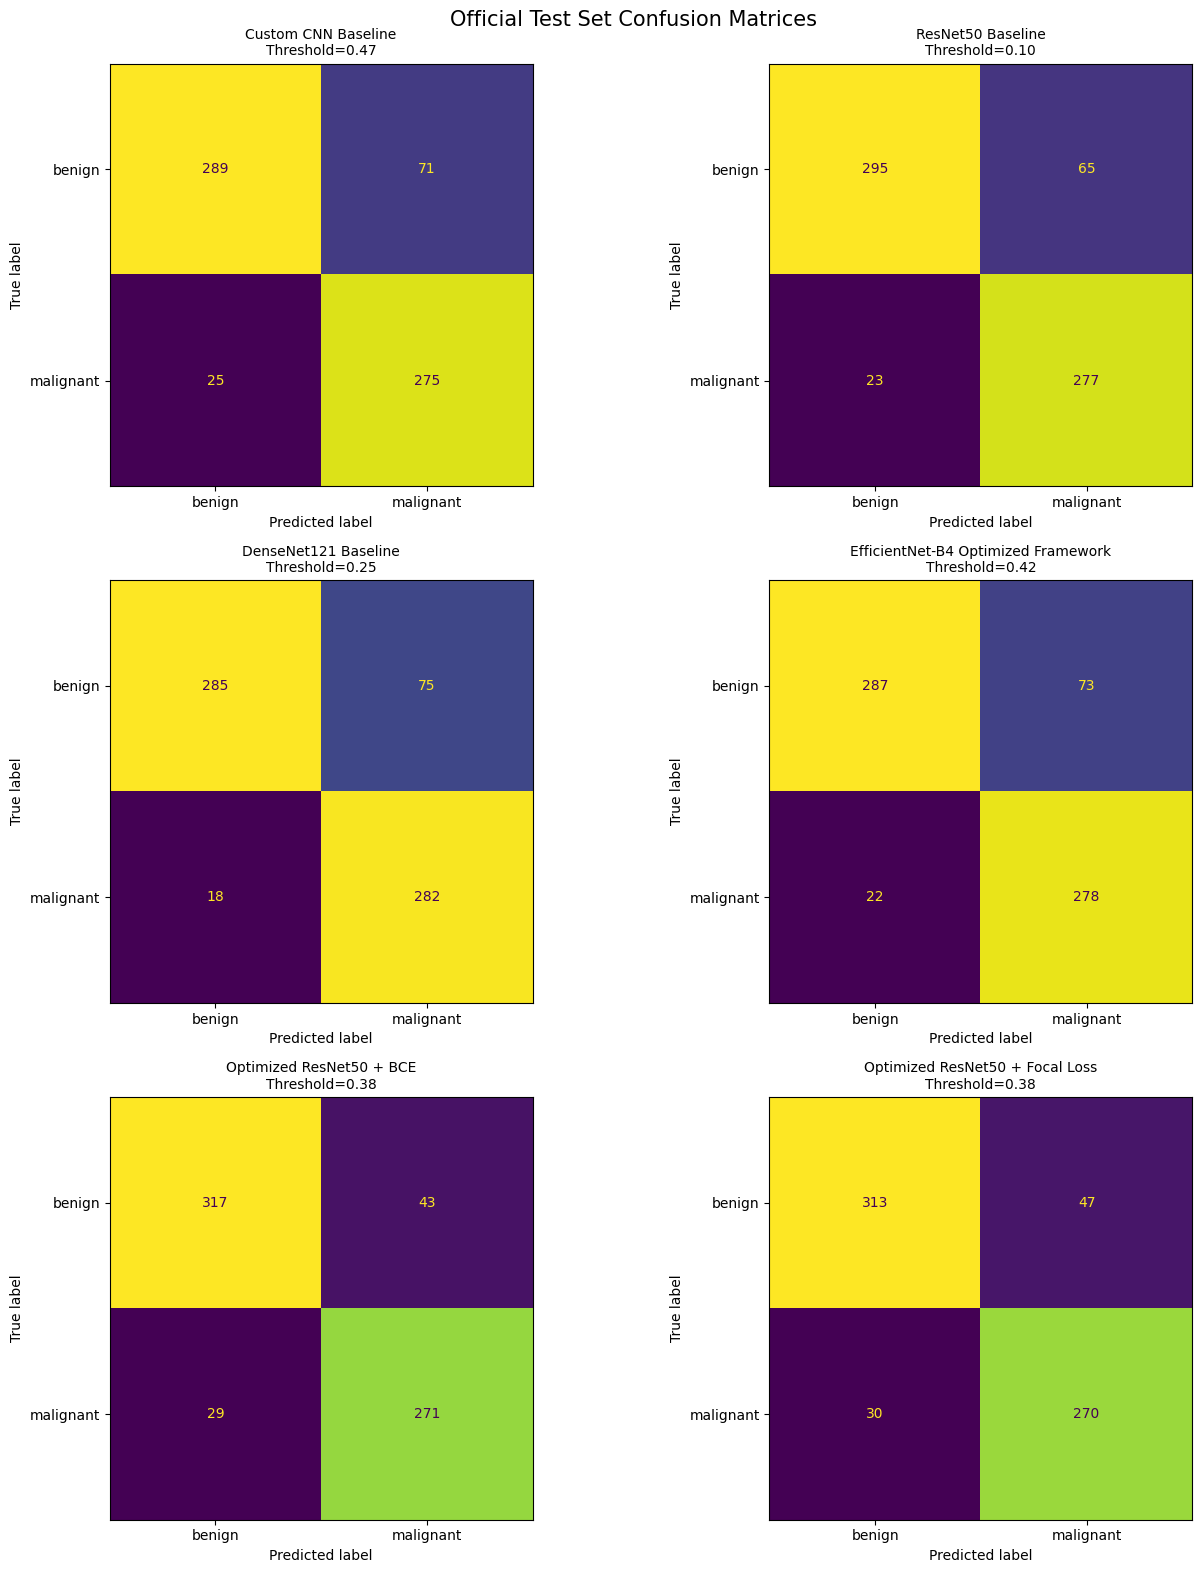

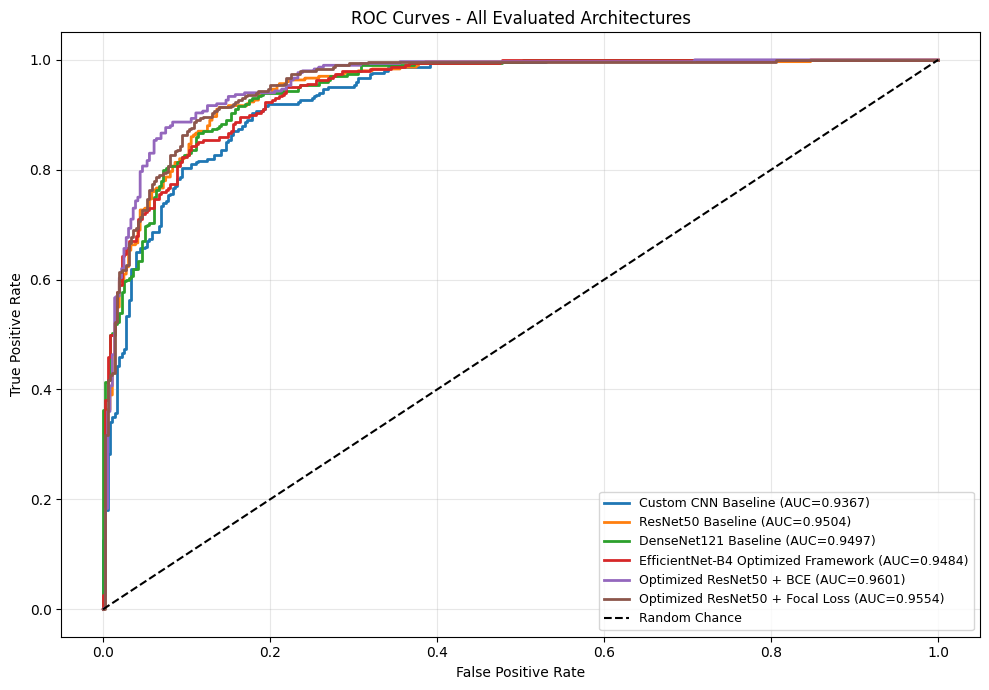

In [22]:
# =====================================================================
# FINAL OFFICIAL TEST SET EVALUATION
# Validation-Frozen Thresholds + Publication Style Tables
# =====================================================================
from IPython.display import display


# ============================================================
# Helper Function: Validation Threshold Optimization
# ============================================================

def find_best_val_threshold(model_obj, val_ds, y_val_data):

    val_probs = model_obj.predict(
        val_ds,
        verbose=0
    ).ravel()


    best_th = 0.50
    best_j = -1.0


    for th in np.arange(0.10, 0.91, 0.01):

        preds = (
            val_probs >= th
        ).astype(int)


        tn, fp, fn, tp = confusion_matrix(
            y_val_data,
            preds
        ).ravel()


        sensitivity = tp / max(
            1,
            tp + fn
        )


        specificity = tn / max(
            1,
            tn + fp
        )


        youden_j = (
            sensitivity +
            specificity -
            1.0
        )


        if youden_j > best_j:

            best_j = youden_j
            best_th = th


    return best_th
    
# ============================================================
# Step 1: Validation Threshold Optimization
# ============================================================


test_thresholds = {}


threshold_models = {

    'Custom CNN Baseline':
        (model_cnn, val_ds_cnn),

    'ResNet50 Baseline':
        (model_res, val_ds_res),

    'DenseNet121 Baseline':
        (model_dense, val_ds_dense),

    'EfficientNet-B4 Optimized Framework':
        (model_eff, val_ds_eff),

    'Optimized ResNet50 + BCE':
        (model_opt_res_bce, val_ds_res),

    'Optimized ResNet50 + Focal Loss':
        (model_opt_res_focal, val_ds_res)

}



print("\n")
print("="*100)
print(" VALIDATION-FROZEN THRESHOLD OPTIMIZATION ")
print("="*100)



threshold_display = []


for mname, (model_obj, val_ds) in threshold_models.items():

    th = find_best_val_threshold(
        model_obj,
        val_ds,
        y_val
    )


    test_thresholds[mname] = th


    threshold_display.append({

        "Model": mname,
        "Optimal Threshold": f"{th:.2f}"

    })



threshold_df = pd.DataFrame(
    threshold_display
)



display(

    threshold_df.style

    .hide(axis="index")

    .set_caption(
        "Validation-Frozen Decision Thresholds"
    )

    .set_table_styles([

        {
            'selector':'caption',
            'props':[
                ('caption-side','top'),
                ('font-size','15px'),
                ('font-weight','bold')
            ]
        }

    ])

    .set_properties(
        **{
            'text-align':'center',
            'font-size':'12pt'
        }
    )

)


# ============================================================
# Step 2: Official Test Evaluation
# ============================================================


test_eval_results = []

test_predictions_dict = {}



test_ds_map = {


    'Custom CNN Baseline':
        (model_cnn, test_ds_cnn),


    'ResNet50 Baseline':
        (model_res, test_ds_res),


    'DenseNet121 Baseline':
        (model_dense, test_ds_dense),


    'EfficientNet-B4 Optimized Framework':
        (model_eff, test_ds_eff),


    'Optimized ResNet50 + BCE':
        (model_opt_res_bce, test_ds_res),


    'Optimized ResNet50 + Focal Loss':
        (model_opt_res_focal, test_ds_res)

}



print("\n")
print("="*100)
print(" OFFICIAL TEST SET EVALUATION ")
print("="*100)



for mname, (mobj, tds) in test_ds_map.items():


    th = test_thresholds[mname]


    probs = mobj.predict(
        tds,
        verbose=0
    ).ravel()


    preds = (
        probs >= th
    ).astype(int)



    test_predictions_dict[mname] = (
        probs,
        preds
    )



    acc, prec, sens, spec, f1, auc = compute_full_metrics(
        y_test,
        probs,
        preds
    )



    test_eval_results.append({

        'Model':mname,

        'Threshold':f"{th:.2f}",

        'Accuracy':f"{acc:.2f}%",

        'Precision':f"{prec:.2f}%",

        'Sensitivity':f"{sens:.2f}%",

        'Specificity':f"{spec:.2f}%",

        'F1-Score':f"{f1:.2f}%",

        'ROC-AUC':f"{auc:.2f}%"

    })





# ============================================================
# TABLE 2: ResNet50 Optimization Comparison
# ============================================================


resnet_df = pd.DataFrame(

    [
        row for row in test_eval_results
        if "ResNet50" in row["Model"]

    ]

)



print("\n")
print("="*100)
print(" TABLE 2: RESNET50 OPTIMIZATION COMPARISON ")
print(" OFFICIAL BENCHMARK TEST SET ")
print("="*100)



display(

    resnet_df.style

    .hide(axis="index")

    .set_caption(
        "ResNet50 Optimization Comparison"
    )

    .highlight_max(
        subset=['ROC-AUC'],
        color='none'
    )

    .highlight_max(
        subset=['F1-Score'],
        color='none'
    )

    .set_properties(
        **{
            'text-align':'center',
            'font-size':'12pt'
        }
    )

)




# ============================================================
# TABLE 1: Full Architecture Comparison
# ============================================================



final_table = pd.DataFrame(
    test_eval_results
)



# Convert metrics

metric_cols = [

    'Accuracy',
    'Precision',
    'Sensitivity',
    'Specificity',
    'F1-Score',
    'ROC-AUC'

]



for col in metric_cols:

    final_table[col] = (

        final_table[col]
        .str.replace('%','')
        .astype(float)

    )



# Rank by ROC-AUC

final_table = final_table.sort_values(

    by=[
        'ROC-AUC',
        'F1-Score'
    ],

    ascending=False

)



final_table.insert(

    0,
    'Rank',
    range(1,len(final_table)+1)

)



# Restore percentage format

for col in metric_cols:

    final_table[col] = final_table[col].apply(

        lambda x:f"{x:.2f}%"

    )



print("\n")
print("="*120)
print(" TABLE 1: BASELINE VS PROPOSED MODEL COMPARISON ")
print(" OFFICIAL BENCHMARK TEST SET ")
print("="*120)



display(

    final_table.style

    .hide(axis="index")

    .set_caption(

        "Performance Comparison of Baseline and Optimized Architectures"

    )


    .highlight_max(

        subset=['ROC-AUC'],

        color='none'

    )


    .highlight_max(

        subset=['F1-Score'],

        color='none'

    )


    .highlight_max(

        subset=['Sensitivity'],

        color='none'

    )


    .set_properties(

        **{

            'text-align':'center',

            'font-size':'12pt'

        }

    )

)



# ============================================================
# Final Proposed Model Summary
# ============================================================


selected_row = final_table[

    final_table['Model']==selected_model_name

]



summary_df = pd.DataFrame({


    "Selected Model":[selected_model_name],


    "Threshold":[

        test_thresholds[selected_model_name]

    ],


    "Accuracy":[

        selected_row['Accuracy'].values[0]

    ],


    "Sensitivity":[

        selected_row['Sensitivity'].values[0]

    ],


    "F1-Score":[

        selected_row['F1-Score'].values[0]

    ],


    "ROC-AUC":[

        selected_row['ROC-AUC'].values[0]

    ]

})




print("\n")
print("="*100)
print(" FINAL PROPOSED MODEL SUMMARY ")
print("="*100)



display(

    summary_df.style

    .hide(axis="index")

    .set_caption(
        "Final Proposed Model Performance"
    )

    .set_properties(

        **{

            'text-align':'center',

            'font-size':'12pt'

        }

    )

)



print("="*100)





# ============================================================
# Confusion Matrices
# ============================================================


fig, axes = plt.subplots(

    3,
    2,
    figsize=(14,16)

)


axes = axes.flatten()



for idx,(mname,(prb,prd)) in enumerate(

    test_predictions_dict.items()

):


    cm = confusion_matrix(

        y_test,

        prd

    )


    disp = ConfusionMatrixDisplay(

        confusion_matrix=cm,

        display_labels=CLASS_NAMES

    )


    disp.plot(

        ax=axes[idx],

        colorbar=False

    )


    axes[idx].set_title(

        f"{mname}\nThreshold={test_thresholds[mname]:.2f}",

        fontsize=10

    )



plt.suptitle(

    "Official Test Set Confusion Matrices",

    fontsize=15

)


plt.tight_layout()

plt.show()




# ============================================================
# ROC Curve Comparison
# ============================================================


plt.figure(

    figsize=(10,7)

)



for mname,(prb,prd) in test_predictions_dict.items():


    fpr,tpr,_ = roc_curve(

        y_test,

        prb

    )


    auc_val = roc_auc_score(

        y_test,

        prb

    )


    plt.plot(

        fpr,

        tpr,

        linewidth=2,

        label=f"{mname} (AUC={auc_val:.4f})"

    )



plt.plot(

    [0,1],

    [0,1],

    'k--',

    linewidth=1.5,

    label="Random Chance"

)



plt.xlabel(
    "False Positive Rate"
)


plt.ylabel(
    "True Positive Rate"
)


plt.title(
    "ROC Curves - All Evaluated Architectures"
)


plt.legend(

    loc='lower right',

    fontsize=9

)


plt.grid(
    alpha=0.3
)


plt.tight_layout()

plt.show()

In [23]:
# ============================================================
# RESTORE FINAL PROPOSED MODEL VARIABLES
# ============================================================


winning_candidate = val_candidates_sorted[0]


selected_model_name = winning_candidate['Model']


best_proposed_model = winning_candidate['model_obj']


best_proposed_backbone = winning_candidate['backbone_obj']


best_threshold = val_metrics_dict[selected_model_name]['Threshold']


best_proposed_test_ds = winning_candidate['test_ds']



print("="*80)
print("FINAL MODEL RESTORED FOR GRAD-CAM")
print("="*80)

print("Selected Model :", selected_model_name)

print("Backbone       :", best_proposed_backbone.name)

print("Threshold      :", best_threshold)

print("="*80)

FINAL MODEL RESTORED FOR GRAD-CAM
Selected Model : Optimized ResNet50 + BCE
Backbone       : resnet50
Threshold      : 0.3799999999999999


In [24]:
# ============================================================
# FINAL MODEL DETAILED METRICS
# ============================================================

print("="*80)
print(" FINAL PROPOSED MODEL DETAILED PERFORMANCE ")
print("="*80)


# Final selected model prediction

final_probs = best_proposed_model.predict(
    best_proposed_test_ds,
    verbose=0
).ravel()


final_preds = (
    final_probs >= best_threshold
).astype(int)



acc, prec, sens, spec, f1, auc = compute_full_metrics(
    y_test,
    final_probs,
    final_preds
)


final_metric_df = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Sensitivity",
        "Specificity",
        "F1-Score",
        "ROC-AUC"
    ],

    "Value":[
        f"{acc:.2f}%",
        f"{prec:.2f}%",
        f"{sens:.2f}%",
        f"{spec:.2f}%",
        f"{f1:.2f}%",
        f"{auc:.2f}%"
    ]

})


display(
    final_metric_df.style
    .hide(axis="index")
    .set_caption(
        "Final Proposed Model Test Performance"
    )
    .set_properties(
        **{
            "text-align":"center",
            "font-size":"12pt"
        }
    )
)

print("="*80)

 FINAL PROPOSED MODEL DETAILED PERFORMANCE 


Metric,Value
Accuracy,89.09%
Precision,86.31%
Sensitivity,90.33%
Specificity,88.06%
F1-Score,88.27%
ROC-AUC,96.01%


## 👁️ 12. Explainable AI: Dynamic Grad-CAM Visual Interpretability

**Robust Graph-Connected Grad-CAM Generator**:
We dynamically inspect `best_proposed_backbone` for `'top_conv'`. If not present by name, we automatically select the final `Conv2D` layer in the selected base model. Gradient tape tracks gradients through a robust Functional graph (`Model(inputs=best_proposed_model.input, outputs=[target_layer.output, best_proposed_model.output])`) with fallback handling for nested layers, model-matched input preprocessing, and resolution matching (`(224, 224)` for ResNet, `(380, 380)` for EfficientNet).

Visualizations are generated for:
1. **True Positive (TP)**: Correctly classified Malignant lesion.
2. **False Negative (FN) / Misclassified**: Missed Malignant case.
3. **True Negative (TN)**: Correctly classified Benign lesion.


GRAD-CAM VERIFICATION
Selected Model : Optimized ResNet50 + BCE
Backbone : resnet50
Target Layer : conv5_block3_out
Grad-CAM Generation: Optimized ResNet50 + BCE

True Positive - Malignant


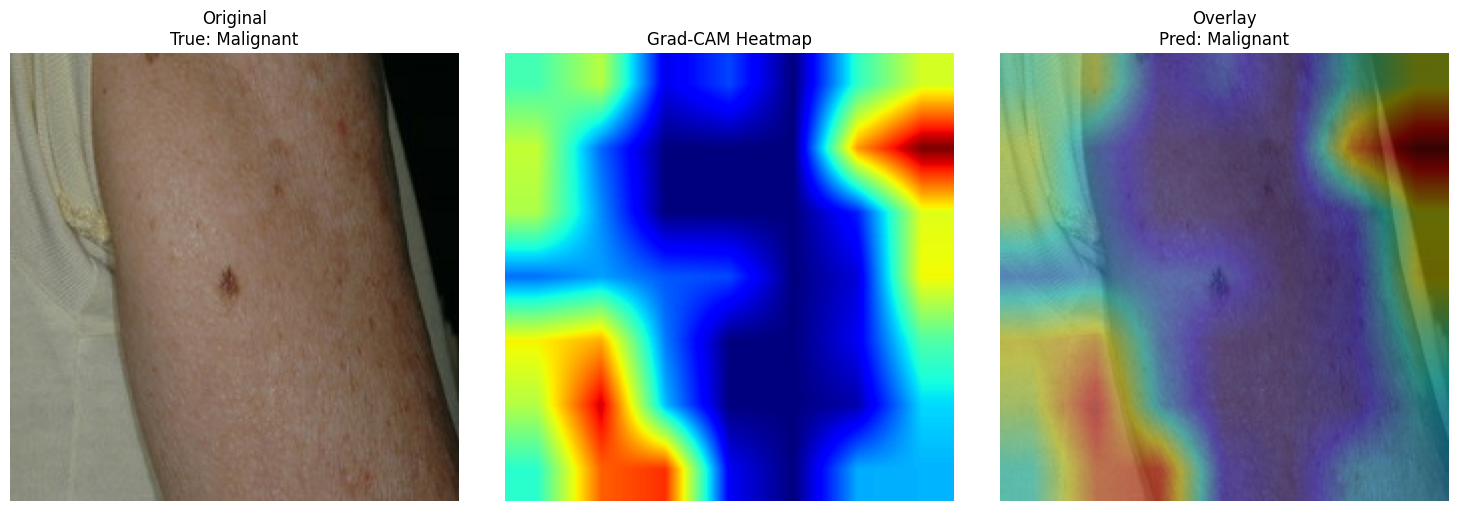


True Negative - Benign


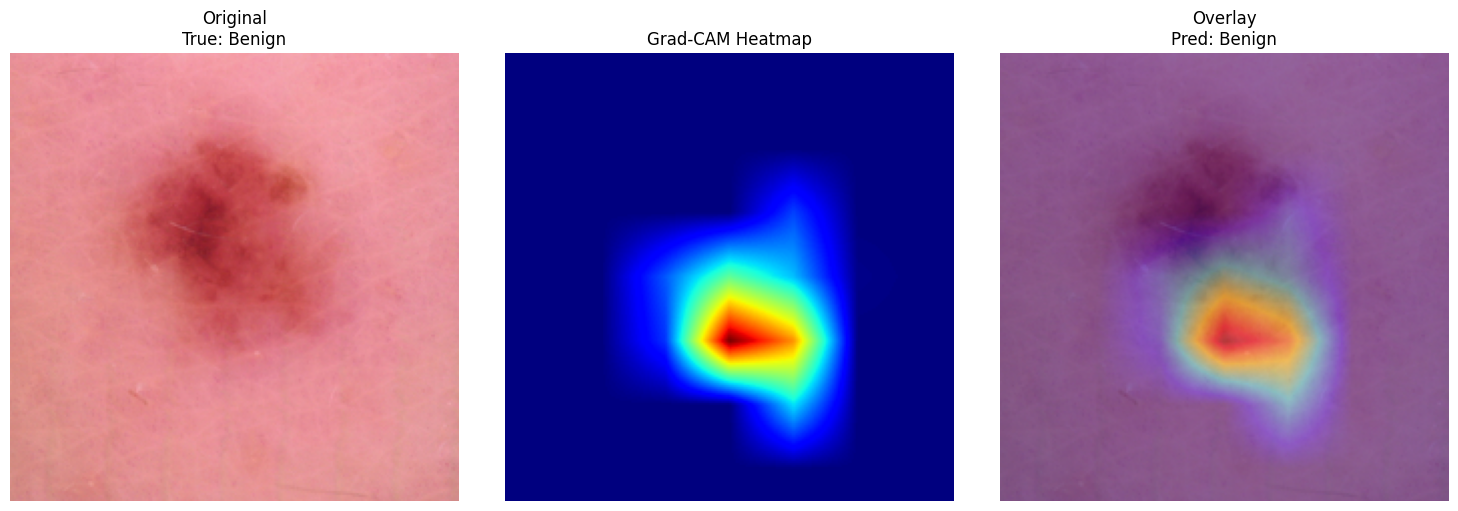


Misclassified Case


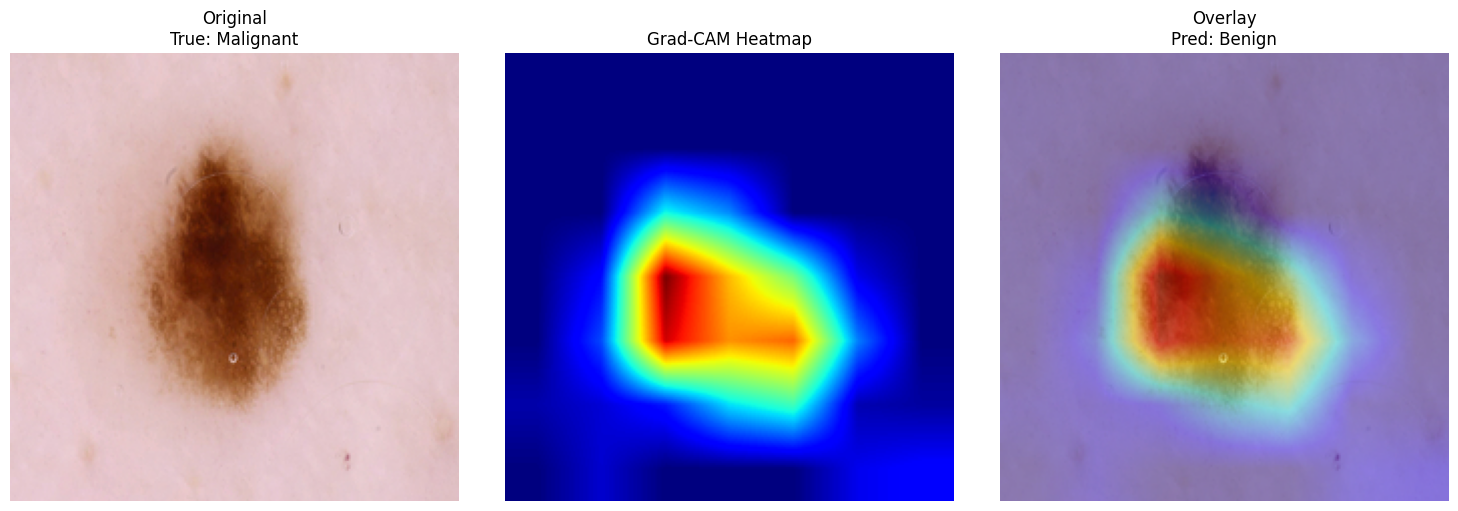

In [25]:
# =====================================================================
# GRAD-CAM EXPLAINABILITY FOR FINAL PROPOSED MODEL
# Graph-Safe Version (ResNet50 + Focal Loss)
# =====================================================================


# -------------------------------------------------------------
# Find last convolution layer
# -------------------------------------------------------------

def get_target_conv_layer(backbone):

    try:
        return backbone.get_layer(
            "conv5_block3_out"
        )

    except:

        for layer in reversed(backbone.layers):

            if isinstance(layer, layers.Conv2D):
                return layer

        raise ValueError(
            "No convolution layer found"
        )



# -------------------------------------------------------------
# Verify selected model
# -------------------------------------------------------------


target_layer = get_target_conv_layer(
    best_proposed_backbone
)


print("="*80)
print("GRAD-CAM VERIFICATION")
print("="*80)

print(
    "Selected Model :",
    selected_model_name
)

print(
    "Backbone :",
    best_proposed_backbone.name
)

print(
    "Target Layer :",
    target_layer.name
)

print("="*80)



# -------------------------------------------------------------
# Build graph-safe GradCAM model
# -------------------------------------------------------------


grad_feature_model = tf.keras.Model(
    inputs=best_proposed_backbone.input,
    outputs=[
        target_layer.output,
        best_proposed_backbone.output
    ]
)



# -------------------------------------------------------------
# Classifier forward pass
# -------------------------------------------------------------


def classifier_forward(features):

    x = features


    # remove backbone connection
    classifier_started = False


    for layer in best_proposed_model.layers:


        if layer == best_proposed_backbone:

            classifier_started = True

            continue


        if classifier_started:

            if isinstance(
                layer,
                layers.InputLayer
            ):
                continue


            x = layer(x)


    return x



# -------------------------------------------------------------
# Grad-CAM Heatmap Generation
# -------------------------------------------------------------


def generate_gradcam_heatmap(
        img_tensor
):


    img = tf.expand_dims(
        img_tensor,
        axis=0
    )


    img = tf.cast(
        img,
        tf.float32
    )


    # ResNet preprocessing

    img = resnet_preprocess(
        img
    )



    with tf.GradientTape() as tape:


        conv_output, features = grad_feature_model(
            img
        )


        tape.watch(
            conv_output
        )


        prediction = classifier_forward(
            features
        )


        loss = prediction[:,0]



    gradients = tape.gradient(
        loss,
        conv_output
    )


    pooled_gradients = tf.reduce_mean(
        gradients,
        axis=(0,1,2)
    )


    conv_output = conv_output[0]


    heatmap = conv_output @ pooled_gradients[...,tf.newaxis]


    heatmap = tf.squeeze(
        heatmap
    )


    heatmap = tf.maximum(
        heatmap,
        0
    )


    heatmap = heatmap / (
        tf.reduce_max(heatmap)
        + 1e-9
    )


    return heatmap.numpy()



# -------------------------------------------------------------
# Plot GradCAM
# -------------------------------------------------------------


def plot_gradcam(
        img_path,
        true_label,
        pred_label,
        size=(224,224)
):


    raw = tf.io.read_file(
        img_path
    )


    img = tf.image.decode_jpeg(
        raw,
        channels=3
    )


    img = tf.image.resize(
        img,
        size
    )



    heatmap = generate_gradcam_heatmap(
        img
    )


    heatmap = cv2.resize(
        heatmap,
        (
            size[1],
            size[0]
        )
    )


    heatmap_color = cv2.applyColorMap(
        np.uint8(
            255*heatmap
        ),
        cv2.COLORMAP_JET
    )


    heatmap_color = cv2.cvtColor(
        heatmap_color,
        cv2.COLOR_BGR2RGB
    )



    original = np.uint8(
        img.numpy()
    )


    overlay = cv2.addWeighted(
        original,
        0.6,
        heatmap_color,
        0.4,
        0
    )



    fig,ax = plt.subplots(
        1,
        3,
        figsize=(15,5)
    )


    ax[0].imshow(
        original
    )

    ax[0].set_title(
        f"Original\nTrue: {true_label}"
    )


    ax[1].imshow(
        heatmap,
        cmap="jet"
    )

    ax[1].set_title(
        "Grad-CAM Heatmap"
    )


    ax[2].imshow(
        overlay
    )

    ax[2].set_title(
        f"Overlay\nPred: {pred_label}"
    )


    for a in ax:
        a.axis("off")


    plt.tight_layout()
    plt.show()



# -------------------------------------------------------------
# Select test samples
# -------------------------------------------------------------


test_probs = best_proposed_model.predict(
    best_proposed_test_ds,
    verbose=0
).ravel()



test_preds = (
    test_probs >= best_threshold
).astype(int)



tp = np.where(
    (y_test==1) &
    (test_preds==1)
)[0]


tn = np.where(
    (y_test==0) &
    (test_preds==0)
)[0]


fn = np.where(
    (y_test==1) &
    (test_preds==0)
)[0]


fp = np.where(
    (y_test==0) &
    (test_preds==1)
)[0]



print(
"Grad-CAM Generation:",
selected_model_name
)



# -------------------------------------------------------------
# TP
# -------------------------------------------------------------


if len(tp)>0:

    print(
        "\nTrue Positive - Malignant"
    )


    plot_gradcam(
        X_test[tp[0]],
        "Malignant",
        "Malignant"
    )



# -------------------------------------------------------------
# TN
# -------------------------------------------------------------


if len(tn)>0:

    print(
        "\nTrue Negative - Benign"
    )


    plot_gradcam(
        X_test[tn[0]],
        "Benign",
        "Benign"
    )



# -------------------------------------------------------------
# Misclassified
# -------------------------------------------------------------


wrong = fn if len(fn)>0 else fp


if len(wrong)>0:

    idx = wrong[0]


    true_label = (
        "Malignant"
        if y_test[idx]==1
        else "Benign"
    )


    pred_label = (
        "Malignant"
        if test_preds[idx]==1
        else "Benign"
    )


    print(
        "\nMisclassified Case"
    )


    plot_gradcam(
        X_test[idx],
        true_label,
        pred_label
    )